In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import glob



# df = df[(df['model'] == 'unigradicon') & (df['dataset'] == 'COPDGene')]

In [2]:

json_file_path = {
    "brain": "./raw_data/l2r_abdomen/brain_model.json",
    "knee": "./raw_data/l2r_abdomen/knee_model.json",
    "lung": "./raw_data/l2r_abdomen/lung_model.json",
    "unigradicon(w/o abdomen)": "./raw_data/l2r_abdomen/unigradicon_three_datasets.json",
    "unigradicon": "./raw_data/l2r_abdomen/unigradicon_model.json",
}

exp_metrics = {}
for k, v in json_file_path.items():
    with open(v, 'r') as file:
        exp_metrics[k] = json.load(file)

initial_metrics = {
    "COPDGene": 23.36,
    "HCP": 53.4,
    "OAI": 7.6,
    "L2R Abdomen": 25.9,
    "ACDC": 58.0
}

def merge_dfs(dfs):
    df_merged = dfs[0]
    for df in dfs[1:]:
        df_merged = pd.merge(df_merged, df, left_index=True, right_index=True, how='inner')
    return df_merged

df = []
for model, metrics in exp_metrics.items():
    metrics_per_model = []
    for k in ["LogJacDetStd", "DiceCoefficient", "HausdorffDistance95"]:
        metric = exp_metrics[model]["case"][k]
        metrics_per_model.append(pd.DataFrame.from_dict(metric, orient='index', columns=[k]))
    metrics_per_model = merge_dfs(metrics_per_model)
    metrics_per_model["model"] = model
    df.append(metrics_per_model)
df = pd.concat(df, axis=0)
df["dataset"] = "L2R Abdomen"

In [3]:
# Load ACDC dataset

ACDC_result_path = {
    "brain": "./raw_data/ACDC/gradicon_brain_model/output.csv",
    "knee": "./raw_data/ACDC/gradicon_knee_model/output.csv",
    "lung": "./raw_data/ACDC/gradicon_lung_model/output.csv",
    "unigradicon(w/o abdomen)": "./raw_data/ACDC/unigradicon(three_dataset)_model/output.csv",
    "unigradicon": "./raw_data/ACDC/unigradicon/output.csv",
}

ACDC_dfs = []
for model, path in ACDC_result_path.items():
    ACDC_df = pd.read_csv(path)
    ACDC_df["model"] = model
    ACDC_df["dataset"] = "ACDC"
    ACDC_dfs.append(ACDC_df)

df = df.rename(columns={"DiceCoefficient": "DICE"})
df = pd.concat([df, pd.concat(ACDC_dfs, axis=0)], axis=0)
df['DICE'] = df['DICE'] * 100

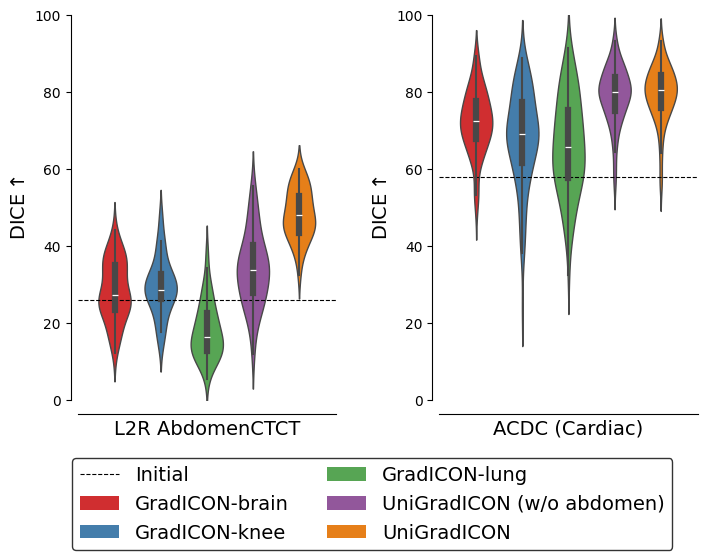

In [6]:
from matplotlib.colors import to_rgb
import pandas as pd 
import seaborn as sns
import matplotlib.gridspec as gridspec

sns.set_palette("Set1")

# Set the style to 'seaborn' for a cleaner look
# plt.style.use('seaborn')

fig = plt.figure(figsize=(8, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1,1])
font_size = 14

dataset_to_plot = df.dataset.unique()


# Set bar width and x positions
# bar_width = 0.02
# x = np.arange(len(datasets))

# Define base colors and adjust gray level
base_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#ADB2D4', '#A5158C']  # Original colors (blue, orange, green)

# Function to adjust color towards gray (desaturate)
def adjust_to_gray(color, gray_level=0.7):
    rgb = np.array(to_rgb(color))  # Convert to RGB tuple
    gray = np.array([gray_level] * 3)  # Gray RGB tuple (same R, G, B values)
    return rgb * (1 - gray_level) + gray * gray_level  # Blend the original color with gray

# Apply the adjust_to_gray function to each color
gray_adjusted_colors = [adjust_to_gray(c, gray_level=0.8) for c in base_colors]

dataset_names = {
    "L2R Abdomen": "L2R AbdomenCTCT",
    "ACDC": "ACDC (Cardiac)",
}
for j, dataset in enumerate(dataset_to_plot):
    ax = plt.subplot(gs[0,j])

    data_to_plot = df[df['dataset'] == dataset]

    # Plot the initial metrics
    ax.axhline(y=initial_metrics[dataset], color='black', linestyle='--', label='Initial', linewidth=0.8)

    # Plot the data
    # ax = sns.barplot(data_to_plot, x="dataset", y="DICE", hue="model", gap=0.1, ax=ax, width=0.5)
    ax = sns.violinplot(data_to_plot, x="dataset", y="DICE", hue="model", gap=0.3, ax=ax, width=0.3, linewidth=1, saturation=0.8)
    ax.legend().set_visible(False)

    ax.set_ylabel(r"DICE$\uparrow$", fontsize=font_size)

    if dataset == "ACDC":
        ax.set_ylim([0, 100])
    elif dataset == "L2R Abdomen":
        ax.set_ylim([0, 100])
    ax.set_xticks([])


    # Adjust the style
    bars = ax.patches

    # Iterate through the bars and set the edge style based on hue
    hue_type = df['model'].unique()
    num_hue_groups = len(hue_type)


    ax.set_xlabel(f"{dataset_names[dataset]}", fontsize=font_size)

    ax.relim()
    ax.margins(0.2)
    ax.autoscale_view()
    

# Add a legend
ax.legend().set_visible(True)
sns.move_legend(ax, frameon=True, facecolor='white', edgecolor='black',
                title="", ncol=2, bbox_to_anchor=(-1.45, -0.13), loc='upper left', fontsize=font_size, borderaxespad=0.4)

# Get the legend object
legend = ax.get_legend()

# Iterate through the legend handles (patches) and remove their edges
for handle in legend.legend_handles[1:]:
    handle.set_edgecolor('none')
    # handle.set_hatch('//')

# Set the legend text
model_names = {
    "brain": "GradICON-brain",
    "lung": "GradICON-lung",
    "knee": "GradICON-knee",
    "unigradicon": "UniGradICON",
    "unigradicon(w/o abdomen)": "UniGradICON (w/o abdomen)",
}
texts = legend.get_texts()
for legend_text in texts:
    if legend_text.get_text() in model_names:
        legend_text.set_text(model_names[legend_text.get_text()])

plt.subplots_adjust(wspace=0.4, hspace=0.4)

sns.despine(offset=(5,10), trim=True)

# Display the plot
# plt.tight_layout()

# plt.show()

plt.savefig('figures/02_generalization_exp_abdomen_and_cardiac.png', bbox_inches='tight', dpi=200, bbox_extra_artists=(legend,))